In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving IMDB Dataset.csv to IMDB Dataset.csv


In [ ]:
df = pd.read_csv(list(uploaded.keys())[0], nrows = 500)

In [ ]:
df.replace({
    'sentiment':{
        'positive': 1,
        'negative': 0
    }
}, inplace = True)

/tmp/ipykernel_2908/1398758754.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({


In [ ]:
df['review'] = df['review'].str.lower()

In [ ]:
df.drop_duplicates(inplace = True)

In [ ]:
import re
def remove_html(text):
  pattern = r'<.*?>'
  text = re.sub(pattern, '', text)
  return text
df['review'] = df['review'].apply(remove_html)

In [ ]:
def remove_punc(text):
  pattern = r'[^a-zA-Z\s]'
  text = re.sub(pattern, '', text)
  return text
df['review'] = df['review'].apply(remove_punc)

In [ ]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
df['review'] = df['review'].apply(
    lambda x: ' '.join([w for w in x.split() if w not in stop_words])
)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
def remove_urls(text):
  url = r'https?://\S+|www\.\S+'
  return re.sub(url, '', text)
df['review'] = df['review'].apply(remove_urls)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
train_data, test_data = train_test_split(df, test_size = 0.2, random_state = 42)

In [ ]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(train_data['review'])
X_train_lstm = pad_sequences(tokenizer.texts_to_sequences(train_data['review']), maxlen=200)
X_test_lstm = pad_sequences(tokenizer.texts_to_sequences(test_data['review']), maxlen=200)
y_train_lstm = train_data['sentiment']
y_test_lstm = test_data['sentiment']

In [ ]:
model = Sequential()
model.add(Embedding(input_dim=5000, output_dim = 128, input_length = 200))
model.add(LSTM(128, dropout = 0.2, recurrent_dropout = 0.2))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
from keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor = 'val_loss', patience = 2, restore_best_weights=True)

In [ ]:
history = model.fit(X_train_lstm, y_train_lstm, validation_data = (X_test_lstm, y_test_lstm), epochs = 10, batch_size = 64, callbacks = [early_stopping], verbose = 1)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 479ms/step - accuracy: 0.5275 - loss: 0.6924 - val_accuracy: 0.4600 - val_loss: 0.6944
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 395ms/step - accuracy: 0.5700 - loss: 0.6801 - val_accuracy: 0.4700 - val_loss: 0.6906
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 453ms/step - accuracy: 0.7075 - loss: 0.6418 - val_accuracy: 0.5700 - val_loss: 0.6718
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 574ms/step - accuracy: 0.9500 - loss: 0.5597 - val_accuracy: 0.7200 - val_loss: 0.6470
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 395ms/step - accuracy: 0.9700 - loss: 0.3898 - val_accuracy: 0.7100 - val_loss: 0.6022
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 439ms/step - accuracy: 0.9500 - loss: 0.2030 - val_accuracy: 0.6800 - val_loss: 0.6024
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 424ms/step - accuracy: 0.9825 - loss: 0.1511 - val_accuracy: 0.6800 - val_loss: 0.6081


In [ ]:
print("Training accuracy: ", history.history['accuracy'][-1])
print("Validation accuracy: ", history.history['val_accuracy'][-1])
print("Training loss: ", history.history['loss'][-1])
print("Validation loss: ", history.history['val_loss'][-1])

Training accuracy:  0.9825000166893005
Validation accuracy:  0.6800000071525574
Training loss:  0.15111982822418213
Validation loss:  0.608079731464386


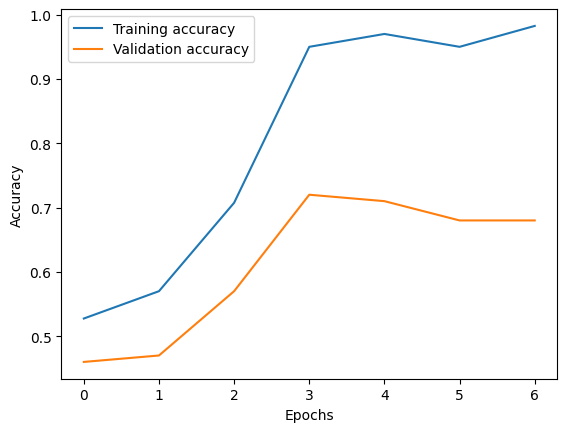

In [ ]:
plt.plot(history.history['accuracy'], label = 'Training accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

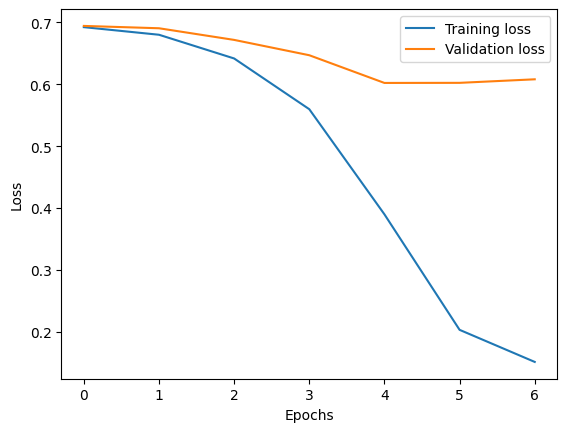

In [ ]:
plt.plot(history.history['loss'], label = 'Training loss')
plt.plot(history.history['val_loss'], label = 'Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
y_pred = model.predict(X_test_lstm)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 146ms/step


In [ ]:
y_pred_classes = (y_pred > 0.5).astype("int32")

In [ ]:
mapping = {
    1: 'positive',
    0: 'negative'
}
print("Top 10 predictions: ")
for i in range(10):
  actual = mapping[y_test_lstm.values[i]]
  predicted = mapping[y_pred_classes[i][0]]
  print(f"Sample {i+1} --> Actual: {actual}, Predicted: {predicted}")

Top 10 predictions: 
Sample 1 --> Actual: negative, Predicted: negative
Sample 2 --> Actual: positive, Predicted: positive
Sample 3 --> Actual: positive, Predicted: positive
Sample 4 --> Actual: negative, Predicted: negative
Sample 5 --> Actual: negative, Predicted: negative
Sample 6 --> Actual: positive, Predicted: positive
Sample 7 --> Actual: negative, Predicted: negative
Sample 8 --> Actual: positive, Predicted: positive
Sample 9 --> Actual: negative, Predicted: negative
Sample 10 --> Actual: positive, Predicted: positive
